# Scenario 6 — 15 x 80 km / 10 GBaud (long-haul, low rate)

Full performance-vs-complexity figure: received SNR (peak over power) vs
complexity [RM/2D] for **EDC, Ideal DBP, OSSFM, LDBP, ESSFM, L-ESSFM**, at the
two oversamplings **n=1.125 (solid)** and **n=2 (dashed)**.

Same link as scenario 03 (15 x 80 km) at a lower symbol rate, so 10 / 32 / 93
GBaud form a clean symbol-rate sweep on a common link.

**Why the long-haul link and not a single span.** On 1 x 170 km at 10 GBaud the
whole DBP family is capped by Ideal DBP at +0.08 dB over EDC, because the
intra-channel nonlinearity that single-channel DBP can remove is a negligible
part of the (inter-channel) NLI at that operating power. Over a long-haul link
the self-channel term accumulates across spans and the headroom comes back.

**Forward.** Generated in `~/ldbp2` and copied to
`forward/forward_scenario_15x80km_10GBd.npy`: 20 powers, `arange(-6, -4, 0.1)`
dBm, one realization each, after a coarse `arange(-8, -2, 1)` dBm sweep.
Two things to keep in mind: the EDC optimum sits at **-6 dBm**, i.e. exactly at
the lower edge of this grid, so the EDC peak-over-power is taken at a boundary;
and the coarse sweep put Ideal DBP at 19.735 dB against 19.532 dB on the fine
grid, a 0.2 dB gap that looks like an n=1.125 / n=2 difference rather than noise.

**Steps needed.** Measured on the first run: L-ESSFM reaches its plateau at
Ns=30, i.e. 2 steps per span, and sits 0.04 dB below it already at Ns=15, one step
per span. Scenario 03 at 93 GBaud on the same link is still improving at Ns=450.
The Ns grid below is set accordingly and is deliberately different from 03's.

**NLPR filter length.** L-ESSFM holds its NLPR kernel at the Ns=1 length (8 taps
at n=1.125, 19 at n=2) for every Ns, instead of letting the per-step formula shrink
it to 4. The frequency-domain complexity does not depend on Nc, so this is free on
the Fig. 1b x axis. ESSFM stays on the formula, which is its published definition.
Models saved with a different length are detected and retrained automatically.

**Cost.** With `RETRAIN = False` the notebook still TRAINS any L-ESSFM / ESSFM
model whose `parameters.csv` is missing, which on a fresh scenario means every
point in `NS_FULL` and `NS_RED`. LDBP is skipped unless its coefficients already
exist. Trim the Ns lists first if you only want a quick look.


In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys, os
_ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(_ROOT, 'core')); os.chdir(_ROOT)
import numpy as np
import matplotlib.pyplot as plt
from system import build_system
from backprop import curve
from complexity import eval_compl, eval_compl_time, complexity_ldbp

SCENARIO = 'scenario_15x80km_10GBd'
RESDIR   = f'results/{SCENARIO}'
L_KM, R_GBD = 1200e3, 10e9
CFG  = {1.125: f'config/{SCENARIO}.ini', 2.0: f'config/{SCENARIO}_n2.ini'}
# Ns grid. NOT the one inherited from scenario 03: at 10 GBaud L-ESSFM saturates
# at Ns=30 (2 steps/span) and is already within 0.04 dB of the plateau at Ns=15
# (1 step/span), so everything scenario 03 spends above Ns=60 buys nothing here
# (Ns=450 costs 12135 RM/2D against 825 at saturation, for +0.000 dB). The budget
# goes into resolving the knee between Ns=1 and Ns=30 instead; 45 and 60 are kept
# as plateau anchors. At 93 GBaud on this same link the curve is still climbing at
# Ns=450, which is the contrast the symbol-rate comparison is about.
NS_FULL = [1,2,3,4,5,6,7,8,9,10,15,30,45,60]   # n=1.125
NS_RED  = [1,3,5,10,15,30,45,60]             # n=2 (reduced)

# NLPR kernel length for L-ESSFM: 'formula' = the per-step rule in nlpr_length(),
# 'ns1' = frozen at the Ns=1 length. Measured at 10 GBaud: the useful support
# saturates at 8 taps, which IS the Ns=1 value, so 'ns1' is free here and slightly
# positive. It does NOT generalise -- at 32 GBaud the same choice costs 0.008 dB
# and puts L-ESSFM below ESSFM, so scenario 07 uses 'formula'.
LESSFM_NFL_MODE = 'ns1'

# RETRAIN: if a method's parameters.csv is missing (or RETRAIN=True), the helpers
# below TRAIN it from scratch with the PyTorch trainer (core/train.py, dual-pol)
# and save it under RESDIR. With RETRAIN=False and the coefficients present, the
# notebook just loads them and simulates (fast, no GPU training).
RETRAIN = False
os.makedirs(RESDIR, exist_ok=True)

# fast training config (Gaussian, short 1024-sym blocks) derived from the scenario
def _train_cfg(nos):
    import re
    base = CFG[nos]
    out = f'config/_train_{SCENARIO}_n{"2" if nos==2.0 else "1125"}.ini'
    s = open(base).read()
    s = s.replace('data symbols per block = 262144', 'data symbols per block = 1024')
    s = re.sub(r'(?m)^modulation = .*', 'modulation = Gaussian', s)
    s = re.sub(r'(?m)^forward steps per span = .*', 'forward steps per span = 50', s)
    open(out, 'w').write(s); return out

## 1. Load the shared forward

In [2]:
# Forward for this scenario: local copy under l_essfm/forward/ (loaded ONCE, reused).
# asarray, not array: the cached arrays are already ndarrays, so this avoids a full
# second copy of a 2 GB file in RAM.
FWD_PATH = f'forward/forward_{SCENARIO}.npy'
fwd = np.load(FWD_PATH, allow_pickle=True).item()
data = {round(10*np.log10(Pw/1e-3), 4): [(np.asarray(y), np.asarray(x)) for (y, x) in r] for Pw, r in fwd.items()}
Pgrid = np.array(sorted(data))
print(f'{len(Pgrid)} powers loaded from {FWD_PATH}: {Pgrid.min():+.2f} .. {Pgrid.max():+.2f} dBm')

20 powers loaded from forward/forward_scenario_15x80km_10GBd.npy: -6.00 .. -4.10 dBm


## 2. Helpers: peak SNR for a method at given Ns and oversampling

In [3]:
def peak(nos, kind, ns, params=None, edc=False):
    S = build_system(CFG[nos])
    ts = False if kind in ('ideal', 'edc') else None
    return curve(S, data, Pgrid, kind, ns, params, edc=edc, total_steps=ts).max()

# --- L-ESSFM NLPR length: selected by LESSFM_NFL_MODE (cell 1) ----------------
# Complexity here is frequency-domain, so the NLPR length Nc does NOT enter C_M:
# a longer kernel is free on the x axis of Fig. 1b. Scenarios 01/02 already
# exploit this (L-ESSFM holds Nc=65/66 while ESSFM's shrinks), but on a 15-span
# link nlpr_length() freezes on the ONE-STEP-PER-SPAN value, which here is 4 taps,
# SHORTER than the 8 taps it uses at Ns=1. So the filter was shrinking with Ns.
# Holding it at the Ns=1 length gives every L-ESSFM model the same kernel support.
# ESSFM is deliberately left on the formula: its Nc-shrinking definition is the
# published reference method (Civelli, "New Twist") and changing it would stop
# the curve from being a comparison against that method.
_NFL = {}
def lessfm_nfl(nos):
    """One-sided NLPR length used for every L-ESSFM model at this oversampling."""
    if nos not in _NFL:
        from train import nlpr_length
        S_ = build_system(CFG[nos])
        _NFL[nos] = nlpr_length(S_, 1) if LESSFM_NFL_MODE == 'ns1' else None
    return _NFL[nos]

def _saved_nfl(path, nos, ns):
    """NLPR length of an already-saved model, recovered from its line count."""
    from system import make_bw
    M = make_bw(build_system(CFG[nos]), ns).model_steps
    n_lines = len(open(path).read().strip().split('\n'))
    return (n_lines - M) // (M - 1)

def lessfm_peak(nos, tag, ns):
    """Peak SNR for L-ESSFM/ESSFM at (nos, ns). Loads parameters.csv if present;
    if missing, stale (saved with a different NLPR length) or RETRAIN, trains it
    with the PyTorch dual-pol trainer and saves."""
    suff = '' if nos == 1.125 else '_n2'
    p = f'{RESDIR}/{tag}{suff}_Ns{ns}/parameters.csv'
    nfl = lessfm_nfl(nos) if tag == 'lessfm' else None
    stale = nfl is not None and os.path.exists(p) and _saved_nfl(p, nos, ns) != nfl
    if RETRAIN or stale or not os.path.exists(p):
        from train import train_lessfm, train_essfm
        Strain = build_system(_train_cfg(nos))
        why = f' (saved nfl != {nfl})' if stale else ''
        print(f'  training {tag} n={nos} Ns={ns}{why} ...', flush=True)
        if tag == 'essfm':
            train_essfm(Strain, ns, p)
        else:
            train_lessfm(Strain, ns, p, nfl=nfl)
    return peak(nos, 'lessfm', ns, p)

from train import nlpr_length as _nl
print(f'L-ESSFM NLPR mode: {LESSFM_NFL_MODE} ->',
      {nos: (lessfm_nfl(nos) if lessfm_nfl(nos) is not None
             else f'formula ({_nl(build_system(CFG[nos]), 1)} at Ns=1)') for nos in CFG})


L-ESSFM NLPR mode: ns1 -> {1.125: 8, 2.0: 19}


## 3. References: EDC, Ideal DBP (both n)

In [4]:
# Ideal DBP: steps are given PER SPAN here (total_steps=False). At 10 GBaud the
# backprop converges very fast: on this link 20, 40 and 80 steps/span agree to
# 0.001 dB, so 20/span (300 total) is already converged.
edc      = peak(1.125, 'edc', 1, edc=True)            # EDC: same SNR at both n
ideal125 = peak(1.125, 'ideal', 20)
ideal2   = peak(2.0,   'ideal', 20)
print(f'EDC {edc:.3f} dB | Ideal n=1.125 DBP {ideal125:.3f} dB | Ideal n=2 DBP {ideal2:.3f} dB')
print(f'DBP headroom over EDC: {ideal2-edc:+.3f} dB (n=2)')

EDC 19.126 dB | Ideal n=1.125 DBP 19.529 dB | Ideal n=2 DBP 19.755 dB
DBP headroom over EDC: +0.628 dB (n=2)


## 4. L-ESSFM and ESSFM, both oversamplings

In [5]:
lessfm125 = {ns: lessfm_peak(1.125,'lessfm',ns) for ns in NS_FULL}
lessfm125 = {k:v for k,v in lessfm125.items() if v is not None}
essfm125  = {ns: lessfm_peak(1.125,'essfm', ns) for ns in NS_FULL}
essfm125  = {k:v for k,v in essfm125.items() if v is not None}
lessfm2   = {ns: lessfm_peak(2.0,'lessfm',ns) for ns in NS_RED}
lessfm2   = {k:v for k,v in lessfm2.items() if v is not None}
essfm2    = {ns: lessfm_peak(2.0,'essfm', ns) for ns in NS_RED}
essfm2    = {k:v for k,v in essfm2.items() if v is not None}
print('L-ESSFM n=1.125:', {k:round(v,3) for k,v in lessfm125.items()})
print('L-ESSFM n=2   :', {k:round(v,3) for k,v in lessfm2.items()})

L-ESSFM n=1.125: {1: np.float64(19.196), 2: np.float64(19.258), 3: np.float64(19.316), 4: np.float64(19.367), 5: np.float64(19.408), 6: np.float64(19.444), 7: np.float64(19.475), 8: np.float64(19.502), 9: np.float64(19.525), 10: np.float64(19.543), 15: np.float64(19.599), 30: np.float64(19.644), 45: np.float64(19.644), 60: np.float64(19.644)}
L-ESSFM n=2   : {1: np.float64(19.243), 3: np.float64(19.417), 5: np.float64(19.519), 10: np.float64(19.632), 15: np.float64(19.683), 30: np.float64(19.739), 45: np.float64(19.751), 60: np.float64(19.753)}


## 5. OSSFM (both n) and LDBP (n=2, pruning sweep)

The LDBP design point is the one knob that does NOT carry over from scenario 03.
At 93 GBaud that notebook uses 20 steps/span (300 total) with 13 to 19 taps each.
Here the per-step CD memory is far shorter: with 2 steps/span (30 total) each step
covers 40 km, whose impulse response spans about 2.2 samples at n=2, so 5 to 9
taps bracket the useful range and 300 steps would be wasted. These values are a
proposal, not a measurement. Nothing trains unless the coefficients already exist
or RETRAIN is set.

In [6]:
from system import make_bw
ossfm125 = {ns: peak(1.125, 'ossfm', ns) for ns in NS_RED}
ossfm125 = {k:v for k,v in ossfm125.items() if v is not None}
ossfm2 = {ns: peak(2.0, 'ossfm', ns) for ns in NS_RED}
ossfm2 = {k:v for k,v in ossfm2.items() if v is not None}
print('OSSFM n=1.125:', {k:round(v,3) for k,v in ossfm125.items()})
print('OSSFM n=2   :', {k:round(v,3) for k,v in ossfm2.items()})

def _ldbp_cfg(logarithmic=True):
    import re
    s = open(CFG[2.0]).read()
    s = s.replace('data symbols per block = 262144', 'data symbols per block = 1024')
    s = re.sub(r'(?m)^modulation = .*', 'modulation = Gaussian', s)
    s = re.sub(r'(?m)^forward steps per span = .*', 'forward steps per span = 50', s)
    if logarithmic:
        s = re.sub(r'(?m)^step size method = .*', 'step size method = logarithmic', s)
    out = f'config/_ldbp_train_{SCENARIO}.ini'; open(out, 'w').write(s); return out

def _ldbp_cfg_eval(logarithmic=True):
    import re
    s = open(CFG[2.0]).read()
    s = re.sub(r'(?m)^modulation = .*', 'modulation = Gaussian', s)
    s = re.sub(r'(?m)^forward steps per span = .*', 'forward steps per span = 50', s)
    if logarithmic:
        s = re.sub(r'(?m)^step size method = .*', 'step size method = logarithmic', s)
    out = f'config/_ldbp_eval_{SCENARIO}.ini'; open(out, 'w').write(s); return out


from ldbp_eval import load_ldbp_params, ldbp_backprop
S_eval = build_system(_ldbp_cfg_eval())
StPS = 1      # number of steps per span (fixed)
LDBP_NS = StPS * build_system(CFG[2.0])['Nsp']       # total steps, for the complexity
bw_eval = make_bw(S_eval, StPS, total_steps=False)

def ldbp_peak(tag, target):
    """target: per-step tap PATTERN (e.g. [9] uniform or [5,3] sawtooth), tiled."""
    p = f'{RESDIR}/ldbp_{tag}/parameters.csv'
    if RETRAIN or not os.path.exists(p):
        from train import train_ldbp
        Strain = build_system(_ldbp_cfg())   # uses 1024 for training (correct)
        M = make_bw(Strain, StPS, total_steps=False).model_steps
        print(f'  training LDBP {tag} (init 21 -> {target}, log step) ...', flush=True)
        train_ldbp(Strain, StPS, p, [21]*M, iters=15000, P_dbm=-5.5, lr=5e-4,
                   target_taps=target, n_blocks=200, total_steps=False)
    cd, nl = load_ldbp_params(p, bw_eval.model_steps)
    snr = [np.mean([ldbp_backprop(S_eval, bw_eval, cd, nl, np.asarray(y), np.asarray(x), 10**(pp/10)*1e-3)
                    for (y, x) in data[pp]]) for pp in Pgrid]
    return max(snr)

def _check_taps(tag, avg):
    """Warn if pruning did not reach the nominal average the complexity assumes."""
    lines = open(f'{RESDIR}/ldbp_{tag}/parameters.csv').read().strip().split('\n')
    got = np.mean([len(lines[3*i].split(',')) for i in range(len(lines)//3)])
    if abs(got - avg) > 0.05:
        print(f'  WARNING {tag}: saved taps average {got:.2f}, complexity assumes {avg}')

# the Fig.1b LDBP points: (tag, target pattern, average taps for complexity).
# Uniform 3 taps is deliberately absent: a 3-tap FIR per step cannot be all-pass
# and correctly dispersive at once, so the 16-step cascade covers 33 samples
# against the ~34 the link needs and lands BELOW EDC. The sawtooth [5,3] reaches
# the same average of 4 with 49 samples of cascade memory, which is why the
# variable pattern works where the uniform one collapses (see the memory note on
# variable-tap pruning).
LDBP_POINTS = [('prune11',[11],11), ('p9',[9],9), ('p7',[7],7),
               ('p5',[5],5), ('v4',[5,3],4)]
ldbp = []
for tag, target, avg in LDBP_POINTS:
    if RETRAIN or os.path.exists(f'{RESDIR}/ldbp_{tag}/parameters.csv'):
        s = ldbp_peak(tag, target); nc = (avg - 1) / 2
        _check_taps(tag, avg)
        ldbp.append((complexity_ldbp(LDBP_NS, nc, 2), s))
ldbp.sort()
print('LDBP points:', [(round(c), round(s,3)) for c, s in ldbp])


OSSFM n=1.125: {1: np.float64(19.126), 3: np.float64(19.127), 5: np.float64(19.148), 10: np.float64(19.435), 15: np.float64(19.579), 30: np.float64(19.579), 45: np.float64(19.578), 60: np.float64(19.578)}
OSSFM n=2   : {1: np.float64(19.126), 3: np.float64(19.127), 5: np.float64(19.148), 10: np.float64(19.459), 15: np.float64(19.748), 30: np.float64(19.755), 45: np.float64(19.755), 60: np.float64(19.755)}
LDBP points: [(306, np.float64(19.655)), (351, np.float64(19.749)), (441, np.float64(19.775)), (531, np.float64(19.782)), (621, np.float64(19.785))]


## 6. The full Fig. 1b

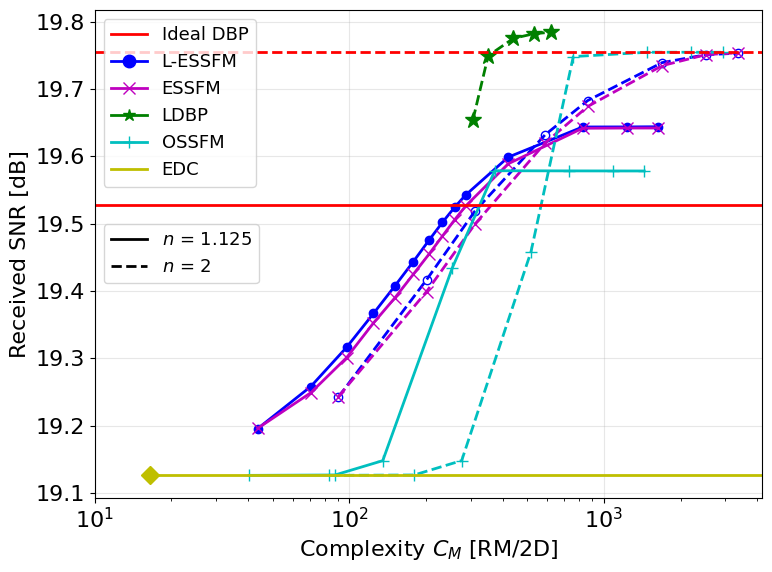

In [7]:
plt.close('all')
C = {'lessfm':'b','essfm':'m','ossfm':'c','ldbp':'g','edc':'y','ideal':'r'}
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['font.size'] = 16
plt.rcParams['lines.markersize'] = 9
fig, ax = plt.subplots(figsize=(8,6))
def cx(d, nos): return [eval_compl(n, nos, L_KM, R_GBD) for n in sorted(d)], [d[n] for n in sorted(d)]
# Each method is costed with its CHEAPEST implementation: time-domain cost grows
# with Nc, frequency-domain cost depends only on the FFT block (Nc-independent).
# ESSFM/L-ESSFM (large Nc) -> frequency; OSSFM (single coefficient, Nc=0) ->
# time (complexityRM_OSSFM_time in Stella's MATLAB), ~14% cheaper.
def cxt(d, nos): return [eval_compl_time(n, nos, L_KM, R_GBD, 0) for n in sorted(d)], [d[n] for n in sorted(d)]
# L-ESSFM
x,y = cx(lessfm125,1.125); ax.plot(x,y,color=C['lessfm'],ls='-',marker='o',ms=6)
if lessfm2: x,y=cx(lessfm2,2.0); ax.plot(x,y,color=C['lessfm'],ls='--',marker='o',mfc='none',ms=6)
# ESSFM
x,y = cx(essfm125,1.125); ax.plot(x,y,color=C['essfm'],ls='-',marker='x',ms=8)
if essfm2: x,y=cx(essfm2,2.0); ax.plot(x,y,color=C['essfm'],ls='--',marker='x',ms=8)
# OSSFM
x,y = cxt(ossfm125,1.125); ax.plot(x,y,color=C['ossfm'],ls='-',marker='+',ms=9)
x,y = cxt(ossfm2,2.0); ax.plot(x,y,color=C['ossfm'],ls='--',marker='+',ms=9)
# LDBP (n=2)
if ldbp: ax.plot([c for c,_ in ldbp],[s for _,s in ldbp],color=C['ldbp'],ls='--',marker='*',ms=12)
# Ideal + EDC
ax.axhline(ideal125,color=C['ideal'],ls='-'); ax.axhline(ideal2,color=C['ideal'],ls='--')
ax.set_xscale('log'); ax.set_xlim(1e1, ax.get_xlim()[1])
x0 = eval_compl(0,1.125,L_KM,R_GBD)
ax.plot([x0, ax.get_xlim()[1]],[edc,edc],color=C['edc'],ls='-'); ax.plot([x0],[edc],color=C['edc'],marker='D',ms=9)
from matplotlib.lines import Line2D
meth=[Line2D([0],[0],color=C['ideal'],label='Ideal DBP'),Line2D([0],[0],color=C['lessfm'],marker='o',label='L-ESSFM'),
      Line2D([0],[0],color=C['essfm'],marker='x',label='ESSFM'),Line2D([0],[0],color=C['ldbp'],marker='*',label='LDBP'),
      Line2D([0],[0],color=C['ossfm'],marker='+',label='OSSFM'),Line2D([0],[0],color=C['edc'],label='EDC')]
sty=[Line2D([0],[0],color='k',ls='-',label='$n$ = 1.125'),Line2D([0],[0],color='k',ls='--',label='$n$ = 2')]
l1=ax.legend(handles=meth,loc='upper left',fontsize=13); ax.add_artist(l1); ax.legend(handles=sty,loc='center left',fontsize=13)
ax.set_xlabel('Complexity $C_M$ [RM/2D]'); ax.set_ylabel('Received SNR [dB]'); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig(f'{RESDIR}/fig1b.png',dpi=110); plt.savefig(f'{RESDIR}/fig1b.svg'); plt.show()

## 7. Same figure vs number of steps $N_s$

Identical layout, but the x-axis is the number of DBP steps $N_s$ instead of the
complexity. EDC (no DBP steps) and Ideal DBP are horizontal references. LDBP is
shown at its best point (full taps) at $N_s$ = `LDBP_NS`.

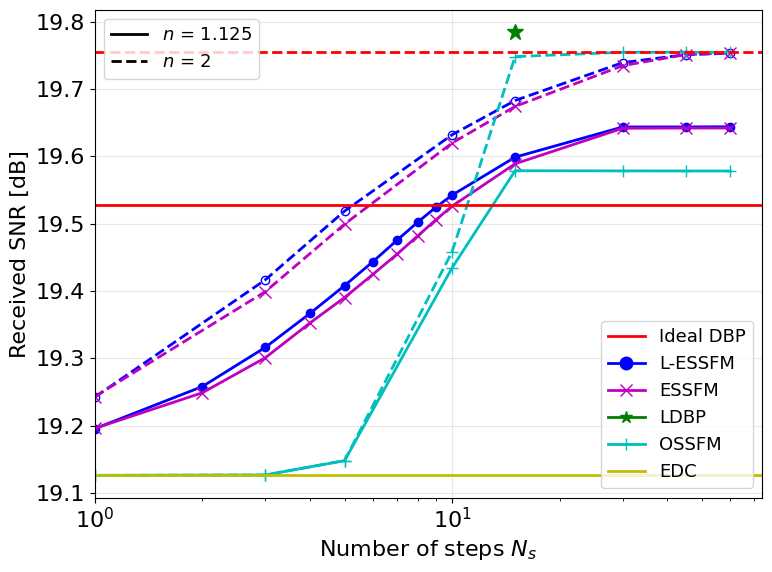

In [8]:
plt.close('all')
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['font.size'] = 16
plt.rcParams['lines.markersize'] = 9
fig, ax = plt.subplots(figsize=(8,6))
# x-axis = number of steps Ns (the dict keys); same colours/markers as Fig.1b
def nx(d): return sorted(d), [d[n] for n in sorted(d)]
# L-ESSFM
x,y = nx(lessfm125); ax.plot(x,y,color=C['lessfm'],ls='-',marker='o',ms=6)
if lessfm2: x,y=nx(lessfm2); ax.plot(x,y,color=C['lessfm'],ls='--',marker='o',mfc='none',ms=6)
# ESSFM
x,y = nx(essfm125); ax.plot(x,y,color=C['essfm'],ls='-',marker='x',ms=8)
if essfm2: x,y=nx(essfm2); ax.plot(x,y,color=C['essfm'],ls='--',marker='x',ms=8)
# OSSFM
x,y = nx(ossfm125); ax.plot(x,y,color=C['ossfm'],ls='-',marker='+',ms=9)
x,y = nx(ossfm2); ax.plot(x,y,color=C['ossfm'],ls='--',marker='+',ms=9)
# LDBP (n=2): single best point (full taps) at N_s=300
if ldbp: ax.plot([LDBP_NS],[max(s for _,s in ldbp)],color=C['ldbp'],ls='none',marker='*',ms=12)
# Ideal + EDC: horizontal references (EDC now also horizontal, no DBP steps)
ax.axhline(ideal125,color=C['ideal'],ls='-'); ax.axhline(ideal2,color=C['ideal'],ls='--')
ax.axhline(edc,color=C['edc'],ls='-')
ax.set_xscale('log'); ax.set_xlim(1e0, ax.get_xlim()[1])
from matplotlib.lines import Line2D
meth=[Line2D([0],[0],color=C['ideal'],label='Ideal DBP'),Line2D([0],[0],color=C['lessfm'],marker='o',label='L-ESSFM'),
      Line2D([0],[0],color=C['essfm'],marker='x',label='ESSFM'),Line2D([0],[0],color=C['ldbp'],marker='*',label='LDBP'),
      Line2D([0],[0],color=C['ossfm'],marker='+',label='OSSFM'),Line2D([0],[0],color=C['edc'],label='EDC')]
sty=[Line2D([0],[0],color='k',ls='-',label='$n$ = 1.125'),Line2D([0],[0],color='k',ls='--',label='$n$ = 2')]
l1=ax.legend(handles=meth,loc='lower right',fontsize=13); ax.add_artist(l1); ax.legend(handles=sty,loc='upper left',fontsize=13)
ax.set_xlabel('Number of steps $N_s$'); ax.set_ylabel('Received SNR [dB]'); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig(f'{RESDIR}/fig_vs_steps.png',dpi=110); plt.savefig(f'{RESDIR}/fig_vs_steps.svg'); plt.show()